In [30]:
# Pour la manipulation de tableaux
import numpy as np
import pandas as pd

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

import itertools


In [31]:
import os
import numpy as np
from keras.utils import load_img, img_to_array

def load_dataset_from_directory(base_dir, img_size, color_mode):
    X = []
    y = []
    class_names = []

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        class_index = len(class_names) - 1

        for root, dirs, files in os.walk(class_path):
            for filename in files:
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    file_path = os.path.join(root, filename)

                    img = load_img(file_path, target_size=img_size, color_mode=color_mode)
                    img_array = img_to_array(img)

                    X.append(img_array)
                    y.append(class_index)

    return np.array(X), np.array(y), class_names

In [32]:
chemin_good=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Train"
chemin_test=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Test"
from tensorflow.keras.preprocessing.image import load_img, img_to_array

train_dir = chemin_good
test_dir  = chemin_test

img_size = (128, 128)   # 
color_mode = "rgb"  # ou "grayscale"


X_train, y_train, class_names_train = load_dataset_from_directory(train_dir, img_size, color_mode)
X_test, y_test, class_names_test = load_dataset_from_directory(test_dir, img_size, color_mode)


# Shape de X_train and y_train
print('Shape of X:', X_train.shape)
print('Shape of y:', y_train.shape)



Shape of X: (5865, 128, 128, 3)
Shape of y: (5865,)


In [33]:
y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test) 

# La méthode *utils.to_categorical* transforme les chiffres en vecteurs
# remplis de zéros, sauf à la position du chiffre en question qui vaut 1 
# Par exemple, 3 devient (0,0,0,1,0,0,0,0,0,0)

# Ainsi y_train et y_test deviennent des matrices de mêmes nombres de lignes mais avec autant
# de colonnes que de classes (chiffres uniques) qu'elles possèdent.

In [34]:
#visualisation du résoltat d'encoding
df_y_train=pd.DataFrame(y_train)
df_y_train
df_y_train_encoded=pd.DataFrame(y_train_encoded)
df_y_train_encoded


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5863,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [37]:
# Instanciation des couches
inputs = Input(shape=(128, 128, 3), name="Input")
normalization_layer = Rescaling(1./255)

first_layer = Conv2D(
    filters=32,
    kernel_size=(5, 5),
    padding='valid',
    activation='relu',
    name='conv_layer1'
)

second_layer = MaxPooling2D(
    pool_size=(2, 2),
    name='max_pooling_layer'
)
x = normalization_layer(inputs)
x = first_layer(x)
x = second_layer(x)
# Instanciation des couches
third_layer = Dropout(rate=0.2)

fourth_layer = Flatten()

fifth_layer = Dense(
    units=128,
    activation='relu',
    name='dense_hidden_layer'
)

output_layer = Dense(
    units=15,
    activation='softmax',
    name='output_layer'
)
# Utilisation des couches
x = third_layer(x)
x = fourth_layer(x)
x = fifth_layer(x)

outputs = output_layer(x)

# Création du modèle
model = Model(inputs=inputs, outputs=outputs)

#####################
model.compile(loss='categorical_crossentropy', # fonction de perte
              optimizer='adam',                # algorithme d'optimisation
              metrics=['accuracy'])            # métrique d'évaluation


In [38]:
from sklearn.utils import shuffle

X_train, y_train_encoded = shuffle(
    X_train,
    y_train_encoded,
    random_state=42
)

training_history = model.fit(X_train, y_train_encoded,
                              validation_split=0.2,
                             epochs=10,
                             batch_size=128)


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 487ms/step - accuracy: 0.6697 - loss: 1.6343 - val_accuracy: 0.8772 - val_loss: 0.2063
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 485ms/step - accuracy: 0.9659 - loss: 0.1113 - val_accuracy: 0.9659 - val_loss: 0.0677
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 521ms/step - accuracy: 0.9795 - loss: 0.0643 - val_accuracy: 0.9037 - val_loss: 0.1771
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 489ms/step - accuracy: 0.9787 - loss: 0.0695 - val_accuracy: 0.9864 - val_loss: 0.0369
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 483ms/step - accuracy: 0.9991 - loss: 0.0127 - val_accuracy: 0.9966 - val_loss: 0.0173
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 483ms/step - accuracy: 0.9996 - loss: 0.0069 - val_accuracy: 0.9966 - val_loss: 0.0158
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 483ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.9974 - val_loss: 0.0123
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 483ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accu

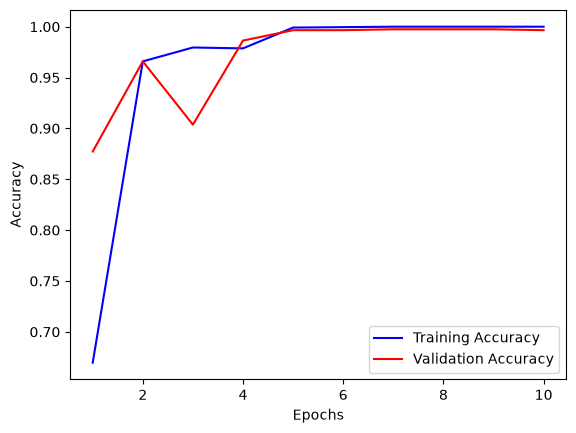

In [39]:
###################
# Labels des axes
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Courbe de la précision sur l'échantillon d'entrainement
plt.plot(np.arange(1 , 11, 1),
         training_history.history['accuracy'],
         label='Training Accuracy',
         color='blue')

# Courbe de la précision sur l'échantillon de test
plt.plot(np.arange(1 , 11, 1),
         training_history.history['val_accuracy'], 
         label='Validation Accuracy',
         color='red')

# Affichage de la légende
plt.legend()

# Affichage de la figure
plt.show()


In [46]:
###############
test_pred = model.predict(X_test)

test_pred_class = test_pred.argmax(axis=1)

y_test_class = y_test_encoded.argmax(axis=1)

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       132
           3       1.00      1.00      1.00       117
           4       0.99      1.00      0.99        78
           5       1.00      1.00      1.00       110
           6       0.98      1.00      0.99       124
           7       1.00      1.00      1.00       115
           8       1.00      1.00      1.00       167
           9       1.00      1.00      1.00       160
          10       1.00      0.99      1.00       117
          11       1.00      1.00      1.00        42
          12       1.00      0.97      0.98       100
          13       1.00      1.00      1.00        79
          14       1.00      1.00      1.00       151

    accuracy                           1.00      1725
   macro avg       1.00      1.00      1.00      1725
weighted avg       1.00   

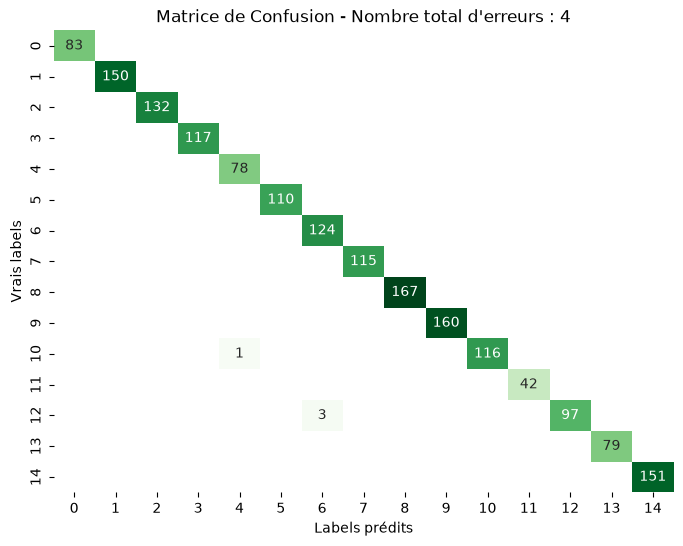

In [47]:
##############
print(metrics.classification_report(y_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)
mask=(cnf_matrix ==0)

#nb total erreurs
nb_erreurs = cnf_matrix.sum() - np.trace(cnf_matrix)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de Confusion - Nombre total d'erreurs : "+str(nb_erreurs))
sns.heatmap(cnf_matrix, cmap='Greens', mask=mask, annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


In [48]:
for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    if cnf_matrix[i, j] > 0.000 and i != j:  # Seuil de 0.0% pour les erreurs significatives
        print(f"{cnf_matrix[i, j]:.0f} des instances de la catégorie {i} ont été classées comme {j}.")

1 des instances de la catégorie 10 ont été classées comme 4.
3 des instances de la catégorie 12 ont été classées comme 6.


4
[1311, 1487, 1488, 1493]
1725


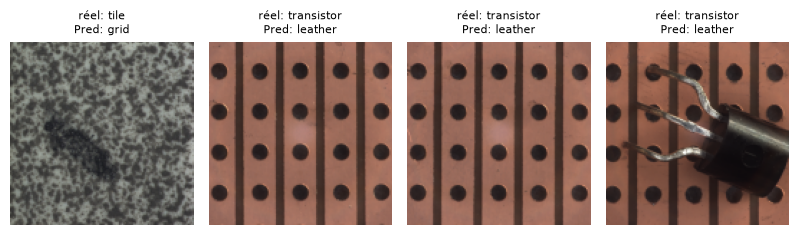

In [49]:
############ Défauts
enr_defauts=[]
for i in range(1,len(y_test)):
        if y_test_class[i] != test_pred_class[i]:
            enr_defauts.append(i)
            
print(len(enr_defauts))
print(enr_defauts)

nb_img_par_couche=10
    
j = 1
plt.figure(figsize=(20, 20))
y_prec=0
num_sortis=[]
print(len(y_test))
for i in enr_defauts:
    img = X_test[i].reshape(128, 128, 3).astype(np.uint8)

    plt.subplot((nb_erreurs // nb_img_par_couche) + 1, nb_img_par_couche, j)
    plt.axis('off')
    plt.imshow(img)

    plt.title(
        f"réel: {class_names_train[y_test_class[i]]}\nPred: {class_names_train[test_pred_class[i]]}",
        fontsize=8
    )
    
    j += 1

               
plt.tight_layout()
plt.show()